In [1]:
import os

from pathlib import Path
from typing import (
    Optional, 
    Dict,
    Any,
    List, 
    Tuple,
)

import pandas as pd
import xarray as xr
import numpy  as np

from tqdm import tqdm
from logger import get_logger
from scipy import stats as scipy_stats
from concurrent.futures import ProcessPoolExecutor, as_completed

from constants import (
    BARRA_CATALOGUE,
    EAR5_CATALOGUE,
    ERA5L_CATALOGUE,
    CREATEIP_CATALOGUE,
    BARRA_VARIABLES
)

logger = get_logger()


QUANTILES = [
    0.01, 0.02, 0.03, 0.04, 0.05,
    0.25, 0.50, 0.75,
    0.95, 0.96, 0.97, 0.98, 0.99
]
MAX_WORKERS = 48


In [2]:
%%time
BARRA = pd.read_csv(BARRA_CATALOGUE, compression='gzip')

BARRA = BARRA[BARRA.source_id == 'BARRA-RE2']
BARRA = BARRA[BARRA.domain_id == 'AUS-22']
BARRA = BARRA[BARRA.freq == 'day']
BARRA = BARRA[BARRA.file_type == 'f']
BARRA = BARRA[BARRA.variable_id.isin(BARRA_VARIABLES)]

# Convert start_time safely: 200501.0 -> 200501 -> datetime
BARRA['start_time'] = pd.to_numeric(
    BARRA['start_time'],
    errors='coerce'
).astype('Int64')

BARRA['start_time'] = pd.to_datetime(
    BARRA['start_time'].astype(str),
    format='%Y%m',
    errors='coerce'
)

# Remove failed dates, if any
BARRA = BARRA.dropna(subset=['start_time'])

# Select last 20 calendar years available
latest_year = BARRA['start_time'].dt.year.max()
start_year = latest_year - 35

BARRA = BARRA[
    BARRA['start_time'].dt.year.between(start_year, latest_year)
]

# Convert back to YYYY-MM
BARRA['start_time'] = BARRA['start_time'].dt.strftime('%Y-%m')

BARRA = (
    BARRA[[
    'variable_id',
    'start_time',
    'path'
    ]]
    .sort_values(by='start_time')
    .reset_index(drop=True)
)

CPU times: user 8.4 s, sys: 719 ms, total: 9.12 s
Wall time: 9.26 s


In [3]:
def extract_metadata_from_netcdf(file_path):
    try:
        with xr.open_dataset(file_path, decode_times=True, chunks={}) as ds:
            dates = []

            if 'time' in ds:
                time_values = ds['time'].values
                dates = [
                    pd.Timestamp(t).strftime('%Y-%m-%d')
                    for t in time_values
                ]

            data_vars = [v for v in ds.data_vars if v not in ds.coords]

            if data_vars:
                var_name = data_vars[0]
                dims = {
                    k: v
                    for k, v in ds[var_name].sizes.items()
                    if k != 'time'
                }
                dimensions = str(dims)
            else:
                dimensions = None

            return {
                'path': file_path,
                'dates': dates,
                'dimensions': dimensions
            }

    except Exception as e:
        return {
            'path': file_path,
            'dates': [],
            'dimensions': None,
            'error': str(e)
        }


def extract_dates_concurrent(
    catalogue: pd.DataFrame,
    max_workers= None,
) -> pd.DataFrame:

    if max_workers is None:
        max_workers = min(8, os.cpu_count() or 1)

    catalogue = catalogue.copy()

    # Remove old date columns if present
    cols_to_drop = ['start_date', 'end_date', 'date', 'dimensions']
    catalogue = catalogue.drop(
        columns=[c for c in cols_to_drop if c in catalogue.columns]
    )

    if 'path' not in catalogue.columns:
        raise ValueError("catalogue must contain a 'path' column")

    file_paths = catalogue['path'].dropna().unique().tolist()
    total_files = len(file_paths)

    logger.info(
        f"Extracting metadata from {total_files} NetCDF files "
        f"using {max_workers} workers..."
    )

    results = {}

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        future_to_path = {
            executor.submit(extract_metadata_from_netcdf, path): path
            for path in file_paths
        }

        with tqdm(
            total=total_files,
            desc="Extracting metadata",
            unit="file"
        ) as pbar:
            for future in as_completed(future_to_path):
                result = future.result()
                results[result['path']] = result
                pbar.update(1)

    expanded_rows = []

    for _, row in catalogue.iterrows():
        path = row['path']
        metadata = results.get(
            path,
            {
                'dates': [],
                'dimensions': None
            }
        )

        dates = metadata.get('dates', [])
        dimensions = metadata.get('dimensions')

        if dates:
            for date in dates:
                new_row = row.to_dict()
                new_row['date'] = date
                new_row['dimensions'] = dimensions
                expanded_rows.append(new_row)
        else:
            new_row = row.to_dict()
            new_row['date'] = None
            new_row['dimensions'] = dimensions
            expanded_rows.append(new_row)

    expanded_df = pd.DataFrame(expanded_rows)

    successful = expanded_df['date'].notna().sum()

    logger.info(
        f"Expanded catalogue: {len(catalogue)} files -> "
        f"{len(expanded_df)} rows ({successful} with dates)"
    )

    return expanded_df

def compute_stats_for_array(data: np.ndarray) -> Optional[Dict[str, float]]:

    data = np.asarray(data, dtype=np.float64).ravel()
    data = data[np.isfinite(data)]

    if data.size == 0:
        return None

    stats_dict = {
        "min": float(np.min(data)),
        "max": float(np.max(data)),
        "mean": float(np.mean(data)),
        "std": float(np.std(data)),
        "median": float(np.median(data)),
        "skewness": float(scipy_stats.skew(data, nan_policy="omit")),
    }

    quantile_values = np.quantile(data, QUANTILES)

    for q, val in zip(QUANTILES, quantile_values):
        stats_dict[f"q{q:.2f}"] = float(val)

    return stats_dict


def extract_stats_from_file_group(
    args: Tuple[str, str, List[str]]
) -> List[Dict[str, Any]]:
    
    file_path, variable_id, date_list = args
    results = []

    try:
        with xr.open_dataset(file_path, decode_times=True) as ds:

            if variable_id not in ds.data_vars:
                for date_str in date_list:
                    results.append({
                        "path": file_path,
                        "variable_id": variable_id,
                        "date": date_str,
                        "stats": None,
                        "error": f"{variable_id} not found in file"
                    })
                return results

            da = ds[variable_id]

            if "time" in da.dims:
                times = pd.to_datetime(ds["time"].values)
                time_dates = np.array([
                    pd.Timestamp(t).strftime("%Y-%m-%d")
                    for t in times
                ])

                for date_str in date_list:
                    date_str = pd.Timestamp(date_str).strftime("%Y-%m-%d")

                    idx = np.where(time_dates == date_str)[0]

                    if len(idx) == 0:
                        results.append({
                            "path": file_path,
                            "variable_id": variable_id,
                            "date": date_str,
                            "stats": None,
                            "error": "date not found in file"
                        })
                        continue

                    data_slice = da.isel(time=idx).values
                    stats = compute_stats_for_array(data_slice)

                    results.append({
                        "path": file_path,
                        "variable_id": variable_id,
                        "date": date_str,
                        "stats": stats,
                        "error": None
                    })

            else:
                data_slice = da.values
                stats = compute_stats_for_array(data_slice)

                for date_str in date_list:
                    date_str = pd.Timestamp(date_str).strftime("%Y-%m-%d")

                    results.append({
                        "path": file_path,
                        "variable_id": variable_id,
                        "date": date_str,
                        "stats": stats,
                        "error": None
                    })

    except Exception as e:
        for date_str in date_list:
            results.append({
                "path": file_path,
                "variable_id": variable_id,
                "date": pd.Timestamp(date_str).strftime("%Y-%m-%d"),
                "stats": None,
                "error": str(e)
            })

    return results


def extract_stats_concurrent(
    catalogue: pd.DataFrame,
    expand_stats: bool = True,
    max_workers = None 
) -> pd.DataFrame:

    if max_workers is None:
        max_workers = min(8, os.cpu_count() or 1)
    
    required_cols = {"path", "variable_id", "date"}
    missing_cols = required_cols - set(catalogue.columns)

    if missing_cols:
        raise ValueError(f"catalogue is missing columns: {missing_cols}")

    catalogue = catalogue.copy()

    # Standardise date format
    catalogue["date"] = pd.to_datetime(
        catalogue["date"],
        errors="coerce"
    ).dt.strftime("%Y-%m-%d")

    # Remove rows without valid dates
    catalogue_valid = catalogue.dropna(subset=["date"]).copy()

    # Group by file and variable so each NetCDF file is opened once
    grouped = (
        catalogue_valid
        .groupby(["path", "variable_id"])["date"]
        .apply(lambda x: sorted(x.dropna().unique().tolist()))
        .reset_index()
    )

    tasks = [
        (row["path"], row["variable_id"], row["date"])
        for _, row in grouped.iterrows()
    ]

    total_tasks = len(tasks)

    logger.info(
        f"Extracting stats from {total_tasks} file-variable groups "
        f"using {max_workers} workers..."
    )

    all_results = []

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        future_to_task = {
            executor.submit(extract_stats_from_file_group, task): task
            for task in tasks
        }

        with tqdm(
            total=total_tasks,
            desc="Extracting stats",
            unit="file-var"
        ) as pbar:
            for future in as_completed(future_to_task):
                result_list = future.result()
                all_results.extend(result_list)
                pbar.update(1)

    results_df = pd.DataFrame(all_results)

    # Merge stats back onto original BARRA_DAILY catalogue
    output = catalogue.merge(
        results_df,
        on=["path", "variable_id", "date"],
        how="left"
    )

    successful = output["stats"].notna().sum()

    logger.info(
        f"Stats extracted: {successful}/{len(output)} rows"
    )

    if expand_stats:
        stats_expanded = pd.json_normalize(output["stats"])

        output = pd.concat(
            [
                output.drop(columns=["stats"]),
                stats_expanded
            ],
            axis=1
        )

    return output


def extract_global_stats(
    df: pd.DataFrame,
    variables: Optional[List[str]] = None,
) -> Dict[str, Dict[str, float]]:
    """
    Extract global statistics per variable from a flat stats DataFrame.

    Expected columns:
    variable_id, min, max, skewness, q0.98, q0.95
    """

    if variables is None:
        variables = BARRA_VARIABLES

    required_cols = [
        "variable_id",
        "min",
        "max",
        "skewness",
        "q0.98",
        "q0.95",
    ]

    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    work = df.copy()

    # Ensure stats columns are numeric
    stat_cols = ["min", "max", "skewness", "q0.98", "q0.95"]

    for col in stat_cols:
        work[col] = pd.to_numeric(work[col], errors="coerce")

    global_stats = {}

    for var in variables:
        sub = work[work["variable_id"] == var]

        values = {
            "_min": sub["min"].min(skipna=True) if not sub.empty else None,
            "_max": sub["max"].max(skipna=True) if not sub.empty else None,
            "_skew": sub["skewness"].max(skipna=True) if not sub.empty else None,
            "_q98": sub["q0.98"].min(skipna=True) if not sub.empty else None,
            "_q95": sub["q0.95"].min(skipna=True) if not sub.empty else None,
        }

        # Convert NaN to None and numpy floats to Python floats
        global_stats[var] = {
            key: None if pd.isna(value) else float(value)
            for key, value in values.items()
        }

    return global_stats
    

In [4]:
%%time
BARRA_DAILY = extract_dates_concurrent(
    catalogue=BARRA,
    max_workers=MAX_WORKERS
)
BARRA_DAILY.groupby('variable_id')['date'].agg(['min', 'max', 'count'])


2026-06-16 14:54:40 | INFO    | 75896451:extract_dates_concurrent:L63 - Extracting metadata from 2120 NetCDF files using 48 workers...
Extracting metadata: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2120/2120 [00:03<00:00, 600.91file/s]
2026-06-16 14:54:45 | INFO    | 75896451:extract_dates_concurrent:L117 - Expanded catalogue: 2120 files -> 64520 rows (64520 with dates)


CPU times: user 1.48 s, sys: 1.11 s, total: 2.6 s
Wall time: 5.39 s


,min,max,count
variable_id,,,
psl,1990-01-01,2025-04-30,12904
ua100m,1990-01-01,2025-04-30,12904
va100m,1990-01-01,2025-04-30,12904
zg500,1990-01-01,2025-04-30,12904
zmla,1990-01-01,2025-04-30,12904


In [5]:
%%time
stats_path = Path("resources/barra-re-daily-stats.csv.gz")

if stats_path.exists():
    print(f"Loading existing stats: {stats_path}")
    BARRA_DAILY_STATS = pd.read_csv(stats_path, compression="gzip")
    GLOBAL_STATS = extract_global_stats(BARRA_DAILY_STATS)
else:
    print("Stats file not found. Computing stats...")

    BARRA_DAILY_STATS = extract_stats_concurrent(
        catalogue=BARRA_DAILY,
        expand_stats=True,
        max_workers=MAX_WORKERS,
    )

    stats_path.parent.mkdir(parents=True, exist_ok=True)

    BARRA_DAILY_STATS.to_csv(
        stats_path,
        index=False,
        compression="gzip"
    )

    GLOBAL_STATS = extract_global_stats(BARRA_DAILY_STATS)
    print(f"Saved stats to: {stats_path}")
    

Loading existing stats: resources/barra-re-daily-stats.csv.gz
CPU times: user 506 ms, sys: 12.7 ms, total: 518 ms
Wall time: 517 ms


In [6]:
GLOBAL_STATS

{'ua100m': {'_min': -40.46923828125,
  '_max': 45.640869140625,
  '_skew': 1.346128286773972,
  '_q98': 9.042724609375,
  '_q95': 7.413818359375},
 'va100m': {'_min': -41.316650390625,
  '_max': 41.2646484375,
  '_skew': 0.7754697916259109,
  '_q98': 5.476806640625,
  '_q95': 4.386962890625},
 'psl': {'_min': 93401.5625,
  '_max': 104783.0625,
  '_skew': 1.4122856812249351,
  '_q98': 101394.125,
  '_q95': 101251.0625},
 'zg500': {'_min': 4660.125,
  '_max': 5975.528645833333,
  '_skew': -0.5261496382191959,
  '_q98': 5834.881510416667,
  '_q95': 5831.702473958333},
 'zmla': {'_min': 30.453125,
  '_max': 5508.96875,
  '_skew': 2.038968155306477,
  '_q98': 1034.40625,
  '_q95': 943.296875}}

In [7]:
import os
import numpy as np
import pandas as pd
import xarray as xr

from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
from plotly.subplots import make_subplots
import plotly.graph_objects as go


PLOT_VARIABLES = [
    "wind100",
    "ua100m",
    "va100m",
    "psl",
    "zg500",
]

VAR_LABELS = {
    "wind100": "100 m wind speed, wind100 (m s⁻¹)",
    "ua100m": "100 m zonal wind, ua100m (m s⁻¹)",
    "va100m": "100 m meridional wind, va100m (m s⁻¹)",
    "psl": "Mean sea-level pressure, psl (hPa)",
    "zg500": "500 hPa geopotential height, zg500 (m)",
    "zmla": "Boundary-layer height, zmla (m)",
}

VAR_SCALE = {
    "wind100": 1.0,
    "ua100m": 1.0,
    "va100m": 1.0,
    "psl": 0.01,      # Pa -> hPa
    "zg500": 1.0,
    "zmla": 1.0,
}

In [8]:
def make_bin_edges_from_stats(
    stats_df: pd.DataFrame,
    variables=PLOT_VARIABLES,
    n_bins: int = 120,
):
    bin_edges = {}

    for var in variables:
        sub = stats_df[stats_df["variable_id"] == var].copy()

        scale = VAR_SCALE.get(var, 1.0)

        # Robust limits from daily spatial quantiles
        lo = pd.to_numeric(sub["q0.01"], errors="coerce").quantile(0.01) * scale
        hi = pd.to_numeric(sub["q0.99"], errors="coerce").quantile(0.99) * scale

        # Fallback to full min/max
        if pd.isna(lo) or pd.isna(hi) or lo == hi:
            lo = pd.to_numeric(sub["min"], errors="coerce").min() * scale
            hi = pd.to_numeric(sub["max"], errors="coerce").max() * scale

        pad = 0.02 * (hi - lo)

        bin_edges[var] = np.linspace(
            lo - pad,
            hi + pad,
            n_bins + 1
        )

    return bin_edges

In [9]:
def histogram_file_worker(args):
    file_path, variable_id, bin_edges, scale = args

    try:
        with xr.open_dataset(file_path, decode_times=False, chunks={}) as ds:

            if variable_id not in ds.data_vars:
                return {
                    "variable_id": variable_id,
                    "path": file_path,
                    "realizations": [],
                    "counts": None,
                    "error": f"{variable_id} not found"
                }

            da = ds[variable_id]

            # Ensure time dimension exists
            if "time" not in da.dims:
                da = da.expand_dims(time=[0])

            # Ensure realization dimension exists
            if "realization" not in da.dims:
                da = da.expand_dims(realization=[0])
                realization_values = np.array([0])
            else:
                if "realization" in ds.coords:
                    realization_values = ds["realization"].values
                else:
                    realization_values = np.arange(da.sizes["realization"])

            other_dims = [
                d for d in da.dims
                if d not in ["time", "realization"]
            ]

            da = da.transpose("time", "realization", *other_dims)

            n_real = da.sizes["realization"]
            n_bins = len(bin_edges) - 1

            counts = np.zeros((n_real, n_bins), dtype=np.int64)

            # Stream one daily time slice at a time
            for t in range(da.sizes["time"]):
                arr = np.asarray(
                    da.isel(time=t).values,
                    dtype=np.float64
                )

                arr = arr * scale

                # Shape: realization x pixels
                arr = arr.reshape(n_real, -1)

                for r in range(n_real):
                    x = arr[r]
                    x = x[np.isfinite(x)]

                    if x.size == 0:
                        continue

                    counts[r] += np.histogram(
                        x,
                        bins=bin_edges
                    )[0]

            return {
                "variable_id": variable_id,
                "path": file_path,
                "realizations": [str(r) for r in realization_values],
                "counts": counts,
                "error": None
            }

    except Exception as e:
        return {
            "variable_id": variable_id,
            "path": file_path,
            "realizations": [],
            "counts": None,
            "error": str(e)
        }

In [10]:
def compute_streaming_histograms(
    catalogue: pd.DataFrame,
    stats_df: pd.DataFrame,
    variables=PLOT_VARIABLES,
    n_bins: int = 120,
    max_workers: int = 8,
):
    bin_edges = make_bin_edges_from_stats(
        stats_df=stats_df,
        variables=variables,
        n_bins=n_bins,
    )

    # One task per unique file-variable pair
    file_catalogue = (
        catalogue[["variable_id", "path"]]
        .drop_duplicates()
        .query("variable_id in @variables")
        .reset_index(drop=True)
    )

    tasks = []

    for _, row in file_catalogue.iterrows():
        var = row["variable_id"]

        tasks.append((
            row["path"],
            var,
            bin_edges[var],
            VAR_SCALE.get(var, 1.0),
        ))

    histograms = {
        var: {}
        for var in variables
    }

    errors = []

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        future_to_task = {
            executor.submit(histogram_file_worker, task): task
            for task in tasks
        }

        with tqdm(
            total=len(tasks),
            desc="Streaming histograms",
            unit="file-var"
        ) as pbar:

            for future in as_completed(future_to_task):
                result = future.result()

                var = result["variable_id"]

                if result["error"] is not None:
                    errors.append(result)
                    pbar.update(1)
                    continue

                counts = result["counts"]
                realizations = result["realizations"]

                for i, realization in enumerate(realizations):
                    if realization not in histograms[var]:
                        histograms[var][realization] = np.zeros(
                            counts.shape[1],
                            dtype=np.int64
                        )

                    histograms[var][realization] += counts[i]

                pbar.update(1)

    print(f"Finished. Errors: {len(errors)}")

    return histograms, bin_edges, errors

In [11]:
histograms, bin_edges, hist_errors = compute_streaming_histograms(
    catalogue=BARRA_DAILY,
    stats_df=BARRA_DAILY_STATS,
    variables=PLOT_VARIABLES,
    n_bins=120,
    max_workers=min(MAX_WORKERS, 32),
)

Streaming histograms: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2120/2120 [11:24<00:00,  3.10file-var/s]


Finished. Errors: 0


In [12]:
def plot_ensemble_frequency_distributions(
    histograms,
    bin_edges,
    variables=PLOT_VARIABLES,
):
    fig = make_subplots(
        rows=3,
        cols=2,
        subplot_titles=[VAR_LABELS[v] for v in variables] + [""],
        vertical_spacing=0.10,
        horizontal_spacing=0.08,
    )

    positions = {
        variables[0]: (1, 1),
        variables[1]: (1, 2),
        variables[2]: (2, 1),
        variables[3]: (2, 2),
        variables[4]: (3, 1),
    }

    for var in variables:
        row, col = positions[var]

        edges = bin_edges[var]
        centers = 0.5 * (edges[:-1] + edges[1:])
        bin_widths = np.diff(edges)

        realization_ids = sorted(
            histograms[var].keys(),
            key=lambda x: int(x) if str(x).isdigit() else str(x)
        )

        density_stack = []

        for realization in realization_ids:
            counts = histograms[var][realization]

            if counts.sum() == 0:
                continue

            density = counts / (counts.sum() * bin_widths)
            density_stack.append(density)

            fig.add_trace(
                go.Scatter(
                    x=centers,
                    y=density,
                    mode="lines",
                    name=f"r{realization}",
                    legendgroup=f"r{realization}",
                    showlegend=(var == variables[0]),
                    opacity=0.35,
                    line=dict(width=1),
                ),
                row=row,
                col=col,
            )

        # Ensemble-mean density
        if density_stack:
            mean_density = np.nanmean(np.vstack(density_stack), axis=0)

            fig.add_trace(
                go.Scatter(
                    x=centers,
                    y=mean_density,
                    mode="lines",
                    name="ensemble mean",
                    legendgroup="ensemble mean",
                    showlegend=(var == variables[0]),
                    line=dict(width=3, dash="dash"),
                ),
                row=row,
                col=col,
            )

        fig.update_xaxes(
            title_text=VAR_LABELS[var],
            row=row,
            col=col,
        )

        fig.update_yaxes(
            title_text="Density",
            row=row,
            col=col,
        )

    # Hide unused subplot
    fig.update_xaxes(visible=False, row=3, col=2)
    fig.update_yaxes(visible=False, row=3, col=2)

    fig.update_layout(
        title="BARRA-RE2 daily frequency distributions by realization",
        width=1250,
        height=950,
        template="plotly_white",
        legend_title="Realization",
    )

    return fig

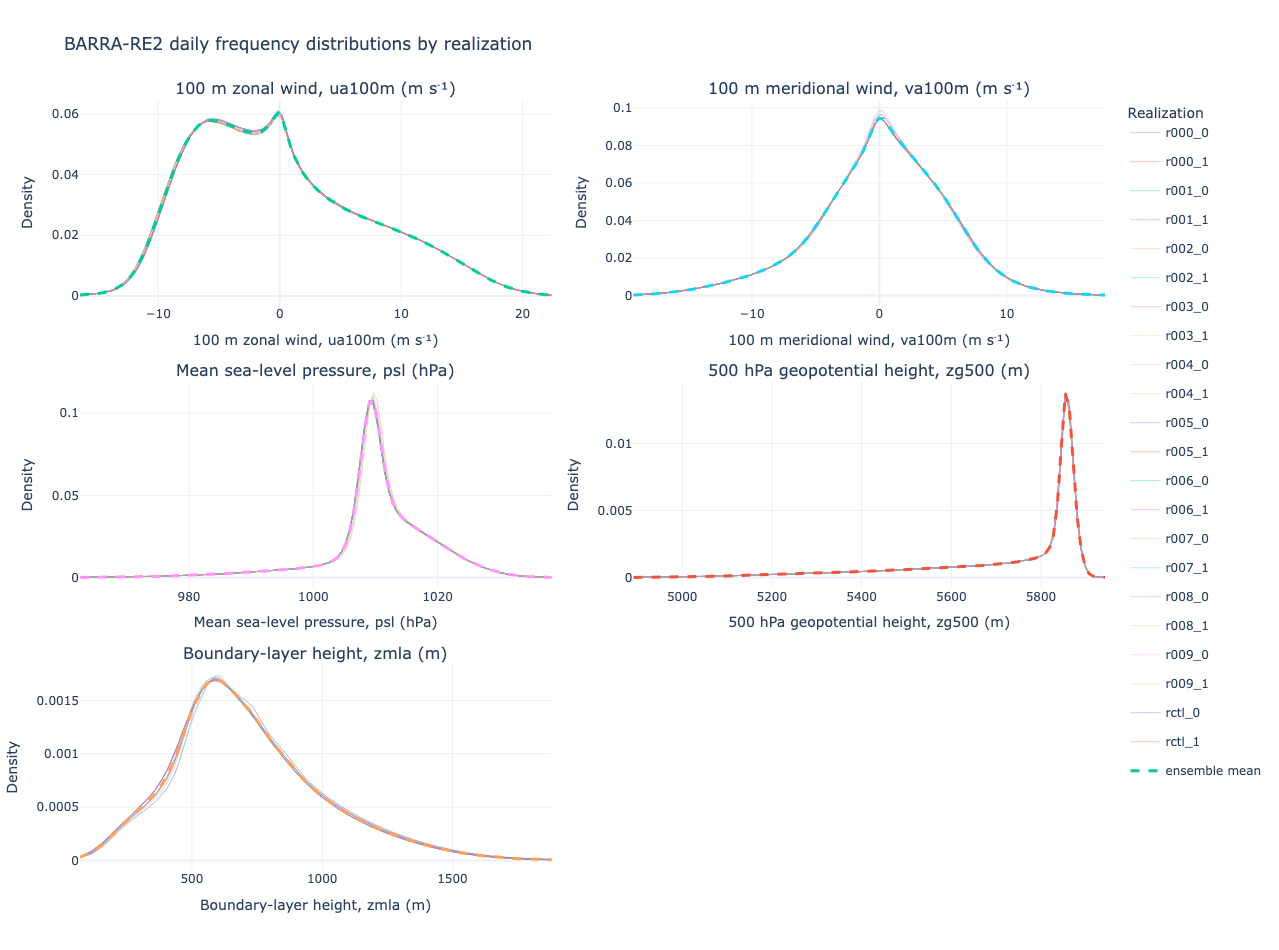

In [13]:
fig = plot_ensemble_frequency_distributions(
    histograms=histograms,
    bin_edges=bin_edges,
    variables=PLOT_VARIABLES,
)

fig.show()